# Imports and configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from typing import Dict
import os
import kagglehub
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter
import ipywidgets as widgets
from IPython.display import display

In [ ]:
np.random.seed(42)

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAVE_STATSMODELS = True
except Exception as e:
    HAVE_STATSMODELS = False
    print("statsmodels not available:", e)


path = kagglehub.dataset_download("artermiloff/steam-games-dataset")

file_path = os.path.join(path, 'games_march2025_cleaned.csv')
df = pd.read_csv(file_path)
display(df.head())

100%|██████████| 418M/418M [00:05<00:00, 73.5MB/s]

Extracting files...


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


# EDA

In [ ]:
print("Rows, Cols:", df.shape)
print("\nDtypes:\n", df.dtypes)

# key date range
print("\nRelease date range:", df['release_date'].min(), "->", df['release_date'].max())

if "appid" in df.columns:
    print("\nUnique appids:", df['appid'].nunique(), " | Duplicate appid rows:", df.duplicated('appid').sum())

Rows, Cols: (89618, 47)

Dtypes:
 appid                         int64
name                         object
release_date                 object
required_age                  int64
price                       float64
dlc_count                     int64
detailed_description         object
about_the_game               object
short_description            object
reviews                      object
header_image                 object
website                      object
support_url                  object
support_email                object
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
metacritic_url               object
achievements                  int64
recommendations               int64
notes                        object
supported_languages          object
full_audio_languages         object
packages                     object
developers                   object
publishers                   o

In [ ]:
# missing values

key_cols = [c for c in [
    'appid', 'name', 'release_date', 'price', 'discount', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent', 'estimated_owners', 'tags'
] if c in df.columns]

miss = df[key_cols].isna().mean().sort_values(ascending=False)
print("Missing fraction (key columns):\n", miss)

Missing fraction (key columns):
 appid                 0.0
name                  0.0
release_date          0.0
price                 0.0
discount              0.0
peak_ccu              0.0
pct_pos_total         0.0
num_reviews_total     0.0
pct_pos_recent        0.0
num_reviews_recent    0.0
estimated_owners      0.0
tags                  0.0
dtype: float64


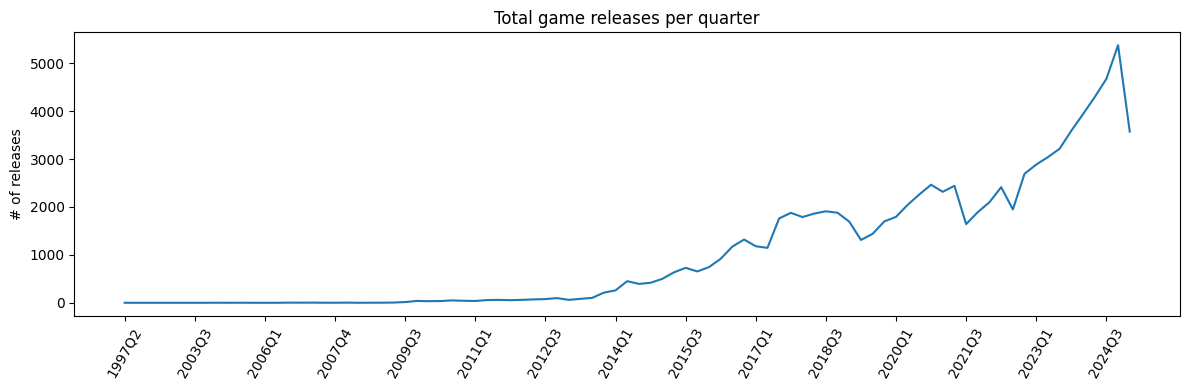

release_q
2022Q2    2414
2022Q3    1949
2022Q4    2694
2023Q1    2886
2023Q2    3041
2023Q3    3216
2023Q4    3592
2024Q1    3938
2024Q2    4293
2024Q3    4674
2024Q4    5377
2025Q1    3573
Freq: Q-DEC, Name: appid, dtype: int64


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors="coerce")
df = df.dropna(subset=['release_date']).copy()

df['release_q'] = df['release_date'].dt.to_period("Q")

releases_q = df.groupby('release_q')['appid'].nunique() if 'appid' in df.columns else df.groupby('release_q').size()
releases_q = releases_q.sort_index()

plt.figure(figsize = (12, 4))
plt.plot(releases_q.index.astype(str), releases_q.values)
plt.xticks(releases_q.index[::6].astype(str), rotation = 60)
plt.title('Total game releases per quarter')
plt.ylabel('# of releases')
plt.tight_layout()
plt.show()

print(releases_q.tail(12))

Figure 1. Total game releases per quarter on Steam. This line chart shows the number of unique games released each quarter (based on appid and release_date). It provides market-wide context and helps justify using quarterly aggregation (reduced noise vs monthly). Visible trends/spikes indicate changes in release volume over time and motivate normalizing tag-level releases using share of total releases.

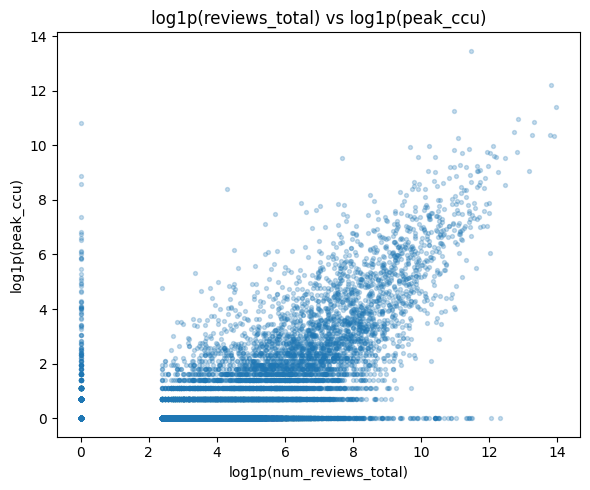

Correlation Matrix:
                log_reviews  log_peak_ccu  pct_pos_total
log_reviews       1.000000      0.594837       0.821464
log_peak_ccu      0.594837      1.000000       0.302609
pct_pos_total     0.821464      0.302609       1.000000


In [ ]:
# peak CCU vs reviews/ratings

cols = [c for c in ['peak_ccu', 'num_reviews_total', 'pct_pos_total'] if c in df.columns]
tmp = df[cols].copy()

for c in cols:
    tmp[c] = pd.to_numeric(tmp[c], errors = "coerce")

tmp['log_peak_ccu'] = np.log1p(tmp['peak_ccu'].fillna(0))
tmp['log_reviews'] = np.log1p(tmp['num_reviews_total'].clip(lower = 0).fillna(0)) if "num_reviews_total" in tmp else np.nan

sample = tmp.dropna().sample(n = min(30000, len(tmp.dropna())), random_state = 42)

plt.figure(figsize = (6, 5))
plt.scatter(sample['log_reviews'], sample['log_peak_ccu'], alpha = 0.25, s = 8)
plt.title('log1p(reviews_total) vs log1p(peak_ccu)')
plt.xlabel('log1p(num_reviews_total)')
plt.ylabel('log1p(peak_ccu)')
plt.tight_layout()
plt.show()

print("Correlation Matrix:\n", sample[['log_reviews', 'log_peak_ccu', 'pct_pos_total']].corr())

Figure 2. Relationship between review volume and player attention (sampled). Each point is a game (random sample up to 30,000). The x-axis is log1p(num_reviews_total) and the y-axis is log1p(peak_ccu). A positive relationship supports using reviews and peak CCU as attention proxies and motivates transforming peak_ccu using log1p due to its heavy-tailed distribution.

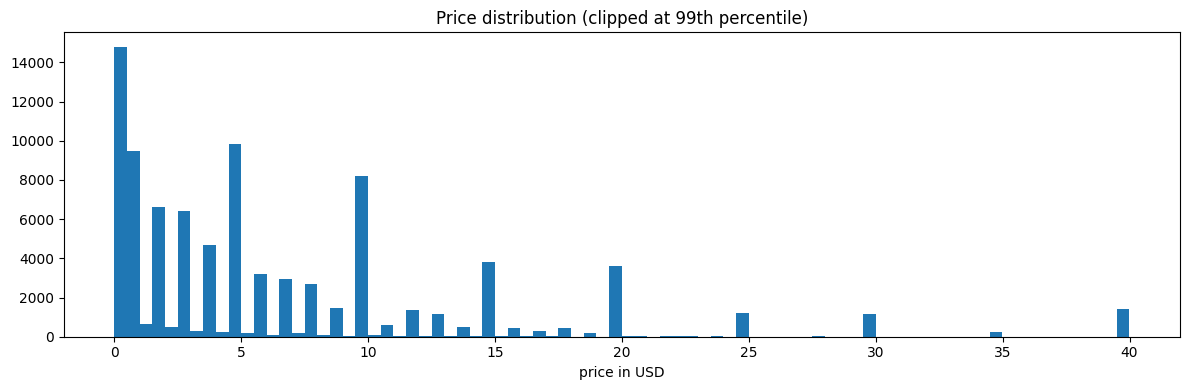

In [ ]:
# price profile

if "price" in df.columns:
    price = pd.to_numeric(df['price'], errors = "coerce")
    plt.figure(figsize = (12, 4))
    plt.hist(price.dropna().clip(upper = price.quantile(0.99)), bins = 80)
    plt.title("Price distribution (clipped at 99th percentile)")
    plt.xlabel("price in USD")
    plt.tight_layout()
    plt.show()

Figure 3. Price distribution (clipped at 99th percentile). Histogram of game prices, with extreme values clipped to improve readability. This plot summarizes the overall pricing and highlights the prevalence of low-priced/free titles, which is useful when interpreting tag trends (some tags may skew toward free-to-play or low-price games).

In [ ]:
# parse tag dict

def parse_tags_dict(x) -> Dict[str, int]:
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return {str(k): int(v) if pd.notna(v) else 0 for k, v in x.items()}
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return {}
        try:
            d = ast.literal_eval(x)
            if isinstance(d, dict):
                out = {}
                for k, v in d.items():
                    try:
                        out[str(k)] = int(v)
                    except Exception:
                        out[str(k)] = 0
                return out
            return {}
        except Exception:
            return {}
    return {}

df['tags_dict'] = df['tags'].apply(parse_tags_dict)
df['tags_count'] = df['tags_dict'].apply(len)

print(df['tags_count'].describe())

# count how many games contain each tag
tag_presence = Counter()

for d in df['tags_dict']:
    for t in d.keys():
        tag_presence[t] += 1

top_tags = pd.DataFrame(tag_presence.most_common(30), columns = ['tag', 'games_in_sample'])
top_tags

count    89618.000000
mean        11.258754
std          7.915154
min          0.000000
25%          4.000000
50%         12.000000
75%         20.000000
max         21.000000
Name: tags_count, dtype: float64


,tag,games_in_sample
0,Indie,43408
1,Singleplayer,42723
2,Action,32315
3,Casual,31832
4,Adventure,30772
5,2D,22695
6,Simulation,15663
7,Strategy,15465
8,3D,14950
9,Puzzle,13923


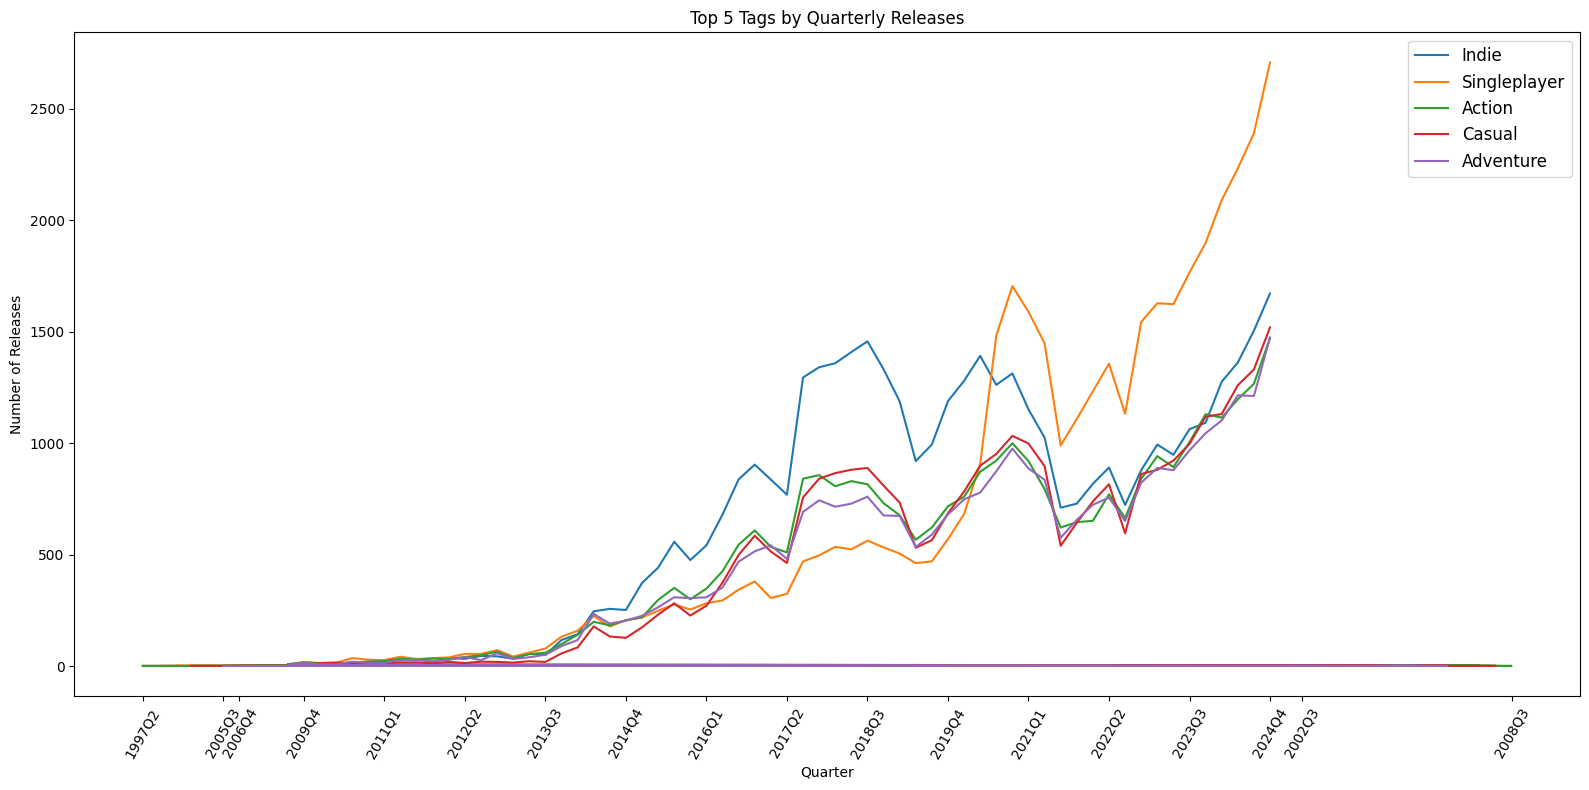

In [ ]:
rows = []

for _, r in df[['appid', 'release_q', 'tags_dict']].iterrows():
    tag_dict = r['tags_dict'] if isinstance(r['tags_dict'], dict) else {}
    for t in tag_dict.keys():
        rows.append((t, r['release_q'], r['appid']))

tag_q = pd.DataFrame(rows, columns = ['tag', 'release_q', 'appid'])
tag_q = (
    tag_q
    .groupby(['tag', 'release_q'])['appid']
    .nunique()
    .reset_index(name = 'releases')
    .sort_values(['tag', 'release_q'])
)

# visualization for top 5 tags
topN = 5

tags_total_releases = tag_q.groupby('tag')['releases'].sum().nlargest(topN).index

tag_q_top_tags = tag_q[tag_q['tag'].isin(tags_total_releases)].copy()

plt.figure(figsize = (16, 8))
for tag in tags_total_releases:
    subset = tag_q_top_tags[tag_q_top_tags['tag'] == tag]
    # Exclude the last data point from the plot
    plt.plot(subset['release_q'].astype(str)[:-1], subset['releases'][:-1], label = tag)

plt.title('Top 5 Tags by Quarterly Releases')
plt.xlabel('Quarter')
plt.ylabel('Number of Releases')
plt.xticks(releases_q.index[::5].astype(str), rotation = 60)
plt.legend(fontsize='large')
plt.tight_layout()
plt.show()

Figure 4. Top 5 tags by quarterly releases (supply trend). For the five most common tags (by total releases in the dataset), this plot shows how many games with each tag were released per quarter. It illustrates how “supply” for major tags evolves over time, and helps motivate later steps that measure tag momentum and classify tags as rising/saturated/declining.

### Snapshot date + maturity cutoff + latest mature quarter

A 180-day maturity cutoff was chosen to reduce censoring from newly released games whose peak attention may not yet be observable.

In [ ]:
SNAPSHOT_DATE = df["release_date"].max()
MATURITY_DAYS = 180

mature_cutoff_date = SNAPSHOT_DATE - pd.Timedelta(days=MATURITY_DAYS)
latest_mature_q = mature_cutoff_date.to_period("Q")

print("Snapshot date:", SNAPSHOT_DATE.date())
print("Mature cutoff date (>=180 days old):", mature_cutoff_date.date())
print("Latest fully mature quarter:", latest_mature_q)

df["is_mature"] = df["release_date"] <= mature_cutoff_date

Snapshot date: 2025-03-10
Mature cutoff date (>=180 days old): 2024-09-11
Latest fully mature quarter: 2024Q3


In [ ]:
# explode to long fomat

candidate_keep_cols = [
    "appid","name","release_date","is_mature",
    "price","discount",
    "peak_ccu","estimated_owners",
    "pct_pos_total","num_reviews_total",
    "pct_pos_recent","num_reviews_recent",
]
keep_cols = [c for c in candidate_keep_cols if c in df.columns]

rows = []
for _, r in df[keep_cols + ["tags_dict"]].iterrows():
    d = r["tags_dict"]
    if not d:
        continue
    base = {c: r[c] for c in keep_cols}
    for tag, weight in d.items():
        rows.append({**base, "tag": tag, "tag_weight": weight})

tags_long = pd.DataFrame(rows)


Although Steam’s raw tag dictionary includes weights, this project treats tag assignment as binary presence to keep tag-quarter supply and attention measures interpretable.

In [ ]:
# create quarterly bin + numeric cleaning + attention transform

tags_long["release_q"] = tags_long["release_date"].dt.to_period("Q")

# Convert some columns to numeric
num_cols = [c for c in [
    "price","discount","peak_ccu","estimated_owners",
    "pct_pos_total","num_reviews_total","pct_pos_recent","num_reviews_recent",
    "tag_weight"
] if c in tags_long.columns]

for c in num_cols:
    tags_long[c] = pd.to_numeric(tags_long[c], errors="coerce")

# peak_ccu: fill missing with 0
if "peak_ccu" in tags_long.columns:
    tags_long["peak_ccu"] = tags_long["peak_ccu"].fillna(0)
else:
    raise ValueError("peak_ccu column missing; cannot proceed with this plan.")

tags_long["log_peak_ccu"] = np.log1p(tags_long["peak_ccu"])
tags_long["ccu_nonzero"] = (tags_long["peak_ccu"] > 0).astype(int)

Tags with fewer than 500 games were excluded to reduce instability in quarter-level momentum estimates.

In [ ]:
# filter tags for stability

tag_counts = tags_long.groupby("tag")["appid"].nunique().sort_values(ascending=False)

MIN_TAG_GAMES = 500
stable_tags = tag_counts[tag_counts >= MIN_TAG_GAMES].index

tags_long_stable = tags_long[tags_long["tag"].isin(stable_tags)].copy()

print("Unique tags total:", tags_long["tag"].nunique())
print("Stable tags:", len(stable_tags))
print("tags_long_stable shape:", tags_long_stable.shape)

tag_counts.head(20)

Unique tags total: 452
Stable tags: 264
tags_long_stable shape: (970097, 17)


,appid
tag,
Indie,43408
Singleplayer,42723
Action,32315
Casual,31832
Adventure,30772
2D,22695
Simulation,15663
Strategy,15465
3D,14950


# Build quarterly supply series (all games)

In [ ]:
total_releases_q = (
    tags_long_stable.groupby("release_q")["appid"]
    .nunique()
    .rename("total_releases_q")
)

supply = (
    tags_long_stable.groupby(["tag","release_q"])["appid"]
    .nunique()
    .rename("releases")
    .reset_index()
)

supply = supply.merge(total_releases_q.reset_index(), on="release_q", how="left")
supply["share"] = supply["releases"] / supply["total_releases_q"]

supply.head()

,tag,release_q,releases,total_releases_q,share
0,1980s,2011Q4,2,55,0.036364
1,1980s,2012Q4,2,97,0.020619
2,1980s,2013Q2,2,83,0.024096
3,1980s,2013Q4,2,194,0.010309
4,1980s,2014Q1,5,258,0.019380


### Build quarterly attention + quality (mature games only, median attention)

The median is used because it is more robust to blockbuster outliers than the mean.

In [ ]:
mature = tags_long_stable[tags_long_stable["is_mature"]].copy()

att_quality = (
    mature
    .groupby(["tag","release_q"])
    .agg(
        # Attention
        att_median=("log_peak_ccu","median"),
        att_mean=("log_peak_ccu","mean"),
        # How often CCU is nonzero in this tag-quarter
        ccu_nz_rate=("ccu_nonzero","mean"),
    )
    .reset_index()
)

def weighted_avg(values, weights):
    m = np.isfinite(values) & np.isfinite(weights)
    if m.sum() == 0:
        return np.nan
    w = weights[m]
    if w.sum() <= 0:
        return np.nan
    return np.average(values[m], weights=w)

tmp = mature.copy()

tmp["pct_pos_total"] = pd.to_numeric(tmp["pct_pos_total"], errors="coerce")
tmp["num_reviews_total"] = pd.to_numeric(tmp["num_reviews_total"], errors="coerce").fillna(0)

tmp["w_reviews"] = tmp["num_reviews_total"].clip(lower=0) + 1

quality = (
    tmp.groupby(["tag","release_q"])
    .apply(lambda g: weighted_avg(g["pct_pos_total"].values, g["w_reviews"].values), include_groups=False)
    .rename("quality_weighted")
    .reset_index()
)

att_quality = att_quality.merge(quality, on=["tag","release_q"], how="left")

In [ ]:
panel = supply.merge(att_quality, on=["tag","release_q"], how="left")
panel = panel.sort_values(["tag","release_q"]).reset_index(drop=True)

panel.head(10)

,tag,release_q,releases,total_releases_q,share,att_median,att_mean,ccu_nz_rate,quality_weighted
0,1980s,2011Q4,2,55,0.036364,0.346574,0.346574,0.500000,74.621622
1,1980s,2012Q4,2,97,0.020619,2.685319,2.685319,0.500000,96.955980
2,1980s,2013Q2,2,83,0.024096,2.845180,2.845180,1.000000,86.635915
3,1980s,2013Q4,2,194,0.010309,2.063567,2.063567,1.000000,73.374048
4,1980s,2014Q1,5,258,0.019380,0.693147,0.415888,0.600000,79.108888
5,1980s,2014Q2,1,448,0.002232,0.000000,0.000000,0.000000,75.000000
6,1980s,2014Q3,1,390,0.002564,1.098612,1.098612,1.000000,88.000000
7,1980s,2014Q4,7,417,0.016787,0.000000,0.328941,0.285714,86.233795
8,1980s,2015Q1,10,496,0.020161,0.000000,0.741216,0.200000,93.366113
9,1980s,2015Q2,4,630,0.006349,0.346574,1.322067,0.500000,96.244399


### Smoothing + momentum features

In [ ]:
EPS = 1e-9

def add_momentum_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("release_q").copy()

    # 2-quarter smoothing
    g["releases_sm"] = g["releases"].rolling(2, min_periods=1).mean()
    g["att_sm"] = g["att_median"].rolling(2, min_periods=1).mean()
    g["share_sm"] = g["share"].rolling(2, min_periods=1).mean()

    # Prior-4 baseline (excluding current quarter)
    g["releases_base4"] = g["releases_sm"].shift(1).rolling(4, min_periods=2).mean()
    g["att_base4"] = g["att_sm"].shift(1).rolling(4, min_periods=2).mean()

    g["supply_mom"] = (g["releases_sm"] - g["releases_base4"]) / (g["releases_base4"] + EPS)
    g["att_mom"] = (g["att_sm"] - g["att_base4"]) / (g["att_base4"] + EPS)

    # Year-over-year share change (4 quarters ago)
    g["share_yoy"] = g["share_sm"] - g["share_sm"].shift(4)
    return g

panel_feat = panel.groupby("tag", group_keys=False).apply(add_momentum_features)

/tmp/ipykernel_1483/3677689981.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel_feat = panel.groupby("tag", group_keys=False).apply(add_momentum_features)


In [ ]:
panel_feat.tail(5)

,tag,release_q,releases,total_releases_q,share,att_median,att_mean,ccu_nz_rate,quality_weighted,releases_sm,att_sm,share_sm,releases_base4,att_base4,supply_mom,att_mom,share_yoy
15053,e-sports,2024Q1,25,2694,0.009280,0.0,0.640044,0.200000,70.761893,25.5,0.0,0.009770,25.625,0.0,-0.004878,0.0,-0.001143
15054,e-sports,2024Q2,27,2849,0.009477,0.0,1.725266,0.407407,82.985409,26.0,0.0,0.009378,26.500,0.0,-0.018868,0.0,-0.002721
15055,e-sports,2024Q3,20,3040,0.006579,0.0,0.767455,0.428571,49.943862,23.5,0.0,0.008028,26.750,0.0,-0.121495,0.0,-0.005079
15056,e-sports,2024Q4,32,3522,0.009086,NaN,NaN,NaN,NaN,26.0,0.0,0.007832,25.500,0.0,0.019608,0.0,-0.003390
15057,e-sports,2025Q1,15,2006,0.007478,NaN,NaN,NaN,NaN,23.5,NaN,0.008282,25.250,0.0,-0.069307,NaN,-0.001489


### Rank tags in the latest fully mature quarter + Trend Index

In [ ]:
latest_q = latest_mature_q
print("Ranking quarter:", latest_q)

latest = panel_feat[panel_feat["release_q"] == latest_q].copy()

# Quality guardrail (only if quality exists)
QUALITY_MIN = 70
if "quality_weighted" in latest.columns:
    latest = latest[latest["quality_weighted"].fillna(-1) >= QUALITY_MIN].copy()

def zscore(s):
    s = s.astype(float)
    mu = np.nanmean(s)
    sd = np.nanstd(s)
    if sd < 1e-12:
        return (s - mu) * 0.0
    return (s - mu) / sd

latest["standardized_Supply"] = zscore(latest["supply_mom"])
latest["standardized_Attention"] = zscore(latest["att_mom"])
latest["standardized_Share"] = zscore(latest["share_yoy"])

latest["trend_index"] = 0.45*latest["standardized_Supply"] + 0.45*latest["standardized_Attention"] + 0.10*latest["standardized_Share"]

latest.sort_values("trend_index", ascending=False).head(15)[
    ["tag","trend_index","standardized_Supply","standardized_Attention","standardized_Share","releases","share","att_median","quality_weighted","ccu_nz_rate"]
]

Ranking quarter: 2024Q3


,tag,trend_index,standardized_Supply,standardized_Attention,standardized_Share,releases,share,att_median,quality_weighted,ccu_nz_rate
3886,Crime,3.104478,1.318815,5.480078,0.449761,52,0.017105,0.693147,91.024942,0.512195
7321,Life Sim,3.097588,1.239820,5.480078,0.736335,133,0.043750,0.693147,90.336431,0.514851
8236,Metroidvania,2.867286,0.959643,5.480078,-0.305886,62,0.020395,0.693147,86.601315,0.520833
7211,LGBTQ+,2.435023,-0.050540,5.480078,-0.082693,61,0.020066,0.693147,89.491484,0.541667
1759,Base-Building,2.354147,-0.252547,5.480078,0.017579,129,0.042434,0.693147,90.131546,0.543478
3691,Cooking,2.223351,-0.518919,5.480078,-0.091704,35,0.011513,0.693147,92.911272,0.520000
1987,Building,2.133846,-0.598874,5.480078,-0.626961,186,0.061184,0.693147,90.717459,0.506757
6150,Grand Strategy,1.859915,-1.262307,5.480078,-0.380817,29,0.009539,0.693147,84.026191,0.521739
14718,Walking Simulator,1.456172,2.780486,-0.188205,2.896452,218,0.071711,0.000000,92.479036,0.164706
3724,Cozy,1.385146,3.048716,-0.188205,0.979158,74,0.024342,0.000000,91.472871,0.490909


Many top tags share very similar attention z-scores in the latest mature quarter, suggesting that the mature-game quarterly attention measure may compress differences at the upper end.

### Classify Rising / Falling / Saturated / Underserved

A z-score threshold of 0.5 was used to represent a practically meaningful deviation from the cross-tag average rather than very small fluctuations.

In [ ]:
def classify(row, z_thresh=0.5):
    zS, zA = row["standardized_Supply"], row["standardized_Attention"]
    if (zS >= z_thresh) and (zA >= z_thresh):
        return "Rising"
    if (zS <= -z_thresh) and (zA <= -z_thresh):
        return "Falling"
    if (zS >= z_thresh) and (zA <= 0):
        return "Saturated"
    if (zS <= 0) and (zA >= z_thresh):
        return "Underserved"
    return "Stable"

latest["state"] = latest.apply(classify, axis=1)

print(latest["state"].value_counts())
latest.sort_values("trend_index", ascending=False).head(10)[["tag","state","trend_index","standardized_Supply","standardized_Attention","quality_weighted"]]

state
Stable         182
Saturated       66
Underserved      5
Rising           3
Name: count, dtype: int64


,tag,state,trend_index,standardized_Supply,standardized_Attention,quality_weighted
3886,Crime,Rising,3.104478,1.318815,5.480078,91.024942
7321,Life Sim,Rising,3.097588,1.239820,5.480078,90.336431
8236,Metroidvania,Rising,2.867286,0.959643,5.480078,86.601315
7211,LGBTQ+,Underserved,2.435023,-0.050540,5.480078,89.491484
1759,Base-Building,Underserved,2.354147,-0.252547,5.480078,90.131546
3691,Cooking,Underserved,2.223351,-0.518919,5.480078,92.911272
1987,Building,Underserved,2.133846,-0.598874,5.480078,90.717459
6150,Grand Strategy,Underserved,1.859915,-1.262307,5.480078,84.026191
14718,Walking Simulator,Saturated,1.456172,2.780486,-0.188205,92.479036
3724,Cozy,Saturated,1.385146,3.048716,-0.188205,91.472871


### Tag plot: supply + attention + quality

In [ ]:
def plot_tag(tag: str):
    g = panel_feat[panel_feat["tag"] == tag].sort_values("release_q").copy()
    if g.empty:
        print("No data for tag:", tag)
        return

    g["q_str"] = g["release_q"].astype("str")

    # Supply
    plt.figure(figsize=(12,4))
    plt.plot(g["q_str"], g["releases"], label="releases", linewidth=1.5)
    plt.plot(g["q_str"], g["releases_sm"], label="releases_sm(2Q)", linewidth=2)
    plt.xticks(rotation=60)
    plt.title(f"{tag} — Supply (releases per quarter)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Attention (median log1p peak_ccu, mature games only)
    plt.figure(figsize=(12,4))
    plt.plot(g["q_str"], g["att_median"], label="att_median (median log1p peak_ccu)", linewidth=1.5)
    plt.plot(g["q_str"], g["att_sm"], label="att_sm(2Q)", linewidth=2)
    plt.xticks(rotation=60)
    plt.title(f"{tag} — Attention (mature games only)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Quality
    if "quality_weighted" in g.columns:
        plt.figure(figsize=(12,4))
        plt.plot(g["q_str"], g["quality_weighted"], label="quality_weighted", linewidth=2)
        plt.axhline(70, linestyle="--", label="quality threshold")
        plt.xticks(rotation=60)
        plt.title(f"{tag} — Quality")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
unique_tags = sorted(panel_feat['tag'].unique().tolist())
print(f"Found {len(unique_tags)} unique tags.")
print(unique_tags[:10])

tag_dropdown = widgets.Dropdown(
    options=unique_tags,
    description='Select Tag:',
    disabled=False,
)

Found 264 unique tags.
['1980s', "1990's", '2.5D', '2D', '2D Fighter', '2D Platformer', '3D', '3D Fighter', '3D Platformer', '3D Vision']


In [ ]:
tag_plot_dropdown = widgets.Dropdown(
    options=unique_tags,
    description='Select Tag to Plot:',
    disabled=False
)

def interactive_plot_tag(tag_name):
    plot_tag(tag_name)

output_plot_tag = widgets.interactive_output(interactive_plot_tag, {'tag_name': tag_plot_dropdown})

display(tag_plot_dropdown, output_plot_tag)

Dropdown(description='Select Tag to Plot:', options=('1980s', "1990's", '2.5D', '2D', '2D Fighter', '2D Platfo…

Output()

Figure 5. Tag supply over time. Quarterly releases for the selected tag, shown as raw counts and a 2-quarter rolling average. This plot is used to evaluate whether the tag’s supply is increasing, stable, or declining and supports the tag’s classification (e.g., Rising vs Falling).

Figure 6. Tag attention over time (mature games only). Attention is measured as the median of log1p(peak_ccu) for games that are at least 180 days old at snapshot time, reducing bias from newly released games that may not have reached their peak. The rolling average highlights sustained changes rather than one-quarter spikes.

Figure 7. Tag quality over time. Weighted average of pct_pos_total, where weights are max(num_reviews_total, 0) + 1 to avoid negative/sentinel review counts. The horizontal line marks the quality threshold (70%). This guardrail helps prevent recommending tags that are growing in volume but have consistently low player satisfaction.

We first use simple statistical forecasting as an interpretable benchmark for release counts, then train a neural network to jointly forecast future releases and attention across tags.

### Forecasting (Quarterly) — Supply + Attention

In [ ]:
def make_series(panel_df: pd.DataFrame, tag: str, ycol: str) -> pd.Series:
    g = panel_df[panel_df["tag"] == tag].sort_values("release_q")
    s = g.set_index("release_q")[ycol].astype(float)
    return s

def seasonal_naive_forecast(series: pd.Series, horizon=4, season=4):
    out = []
    for h in range(1, horizon+1):
        out.append(series.iloc[-season + ((h-1) % season)])
    return np.array(out)

def last_value_forecast(series: pd.Series, horizon=4):
    return np.repeat(series.iloc[-1], horizon)

def rolling_mean_forecast(series: pd.Series, horizon=4, window=4):
    m = np.nanmean(series.iloc[-window:])
    return np.repeat(m, horizon)

def ets_forecast(series: pd.Series, horizon=4, season=4):
    if not HAVE_STATSMODELS:
        raise RuntimeError("statsmodels not available")
    y = series.astype(float)

    model = ExponentialSmoothing(
        y,
        trend="add",
        seasonal="add",
        seasonal_periods=season,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    fc = fit.forecast(horizon)
    return np.array(fc)

def smape(y_true, y_pred, eps=1e-9):
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return np.mean(2*np.abs(y_pred - y_true)/denom)

def backtest_one(series: pd.Series, horizon=4, season=4, min_train=20):
    s = series.dropna()
    if len(s) < (min_train + horizon + season):
        return None

    idx = s.index
    vals = s.values

    errs = {"last": [], "seasonal": [], "mean": [], "ets": []}

    for end in range(min_train, len(vals) - horizon + 1):
        train = pd.Series(vals[:end], index=idx[:end])
        test = vals[end:end+horizon]

        p_last = last_value_forecast(train, horizon)
        p_seas = seasonal_naive_forecast(train, horizon, season=season)
        p_mean = rolling_mean_forecast(train, horizon, window=season)

        errs["last"].append(smape(test, p_last))
        errs["seasonal"].append(smape(test, p_seas))
        errs["mean"].append(smape(test, p_mean))

        if HAVE_STATSMODELS:
            try:
                p_ets = ets_forecast(train, horizon=horizon, season=season)
                errs["ets"].append(smape(test, p_ets))
            except Exception:
                pass

    out = {k: float(np.mean(v)) if len(v) else np.nan for k, v in errs.items()}
    return out

### Backtest forecasts for releases

Backtesting was limited to tags with the longest quarterly histories to ensure enough observations for rolling evaluation.

In [ ]:
# Choose forecast candidates with longest history
candidate_tags = (
    panel_feat.groupby("tag")["release_q"]
    .nunique()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

results = []
for tag in candidate_tags:
    s_rel = make_series(panel_feat, tag, "releases").fillna(0)
    bt = backtest_one(s_rel, horizon=4, season=4, min_train=20)
    if bt is None:
        continue
    results.append({"tag": tag, "target": "releases", **bt})

bt_releases = pd.DataFrame(results).sort_values("seasonal")
bt_releases.head(15)

,tag,target,last,seasonal,mean,ets
22,Difficult,releases,0.233401,0.307863,0.291848,0.827992
16,Co-op,releases,0.253761,0.313483,0.292317,0.620007
28,Sandbox,releases,0.249138,0.318012,0.290638,0.377124
2,Multiplayer,releases,0.239005,0.323602,0.300837,0.789379
17,Fantasy,releases,0.251175,0.331310,0.304974,0.646092
3,Strategy,releases,0.257828,0.340601,0.316601,0.518582
26,Open World,releases,0.266388,0.343718,0.302773,0.617792
7,RPG,releases,0.251110,0.349970,0.323655,0.559686
11,Story Rich,releases,0.285255,0.353351,0.334058,0.632230
18,Third Person,releases,0.277453,0.354346,0.311715,0.644839


### Plot forecasts for tags

In [ ]:
def plot_forecast(tag: str, horizon=4):
    s = make_series(panel_feat, tag, "releases").fillna(0)
    q = s.index.astype(str)
    y = s.values

    if HAVE_STATSMODELS:
        try:
            fc = ets_forecast(s, horizon=horizon, season=4)
            label = "ETS"
        except:
            fc = seasonal_naive_forecast(s, horizon=horizon, season=4)
            label = "Seasonal naive"
    else:
        fc = seasonal_naive_forecast(s, horizon=horizon, season=4)
        label = "Seasonal naive"

    future_q = []
    last_q = s.index[-1]
    for i in range(1, horizon+1):
        future_q.append((last_q + i).strftime("%YQ%q") if hasattr(last_q, "strftime") else str(last_q + i))

    plt.figure(figsize=(12,4))
    plt.plot(list(q[:-1]), list(y[:-1]), label="history") # Exclude the last historical data point
    plt.plot(future_q, fc, marker="o", label=f"forecast ({label})")

    # Combine historical and forecasted quarter labels and select every 5th one
    all_x_labels = list(q[:-1]) + future_q
    plt.xticks(all_x_labels[::max(1, len(all_x_labels) // 12)], rotation = 60)
    plt.title(f"{tag} — Releases forecast (next {horizon} quarters)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def interactive_plot_forecast(tag):
    plot_forecast(tag)

display(tag_dropdown)
output = widgets.interactive_output(interactive_plot_forecast, {'tag': tag_dropdown})
display(output)

Dropdown(description='Select Tag:', index=69, options=('1980s', "1990's", '2.5D', '2D', '2D Fighter', '2D Plat…

Output()

Figure 8. Statistical forecast of tag releases. This plot shows historical quarterly releases and a 4-quarter ahead forecast. The forecast uses Exponential Smoothing (ETS) when available, with a fallback to a seasonal-naive baseline if ETS fails. This provides a simple, explainable prediction of future supply and is validated via rolling backtests in the forecasting section.

# NN

The neural forecast is intended as a proof-of-concept predictive model rather than a fully tuned forecasting system.

### Create tag_id mapping and supervised table

In [ ]:
L = 8          # input window: last 8 quarters
H = 4          # forecast horizon: next 4 quarters
FEATURE_COLS_BASE = ["releases", "share", "att_median", "quality_weighted"]
MOM_COLS = ["supply_mom", "att_mom", "share_yoy"]

def make_supervised_with_horizon(panel_feat: pd.DataFrame, lag=L, horizon=H):
    df = panel_feat.copy().sort_values(["tag", "release_q"])
    df["release_q"] = df["release_q"].astype("period[Q]")

    # Targets (transform)
    df["y_releases"] = np.log1p(df["releases"].fillna(0)).astype(float)
    df["y_att"] = df["att_median"].astype(float)

    # tag_id
    tags = sorted(df["tag"].dropna().unique())
    tag2id = {t:i for i,t in enumerate(tags)}
    df["tag_id"] = df["tag"].map(tag2id).astype(int)

    rows = []
    for tag, g in df.groupby("tag", sort=False):
        g = g.sort_values("release_q").reset_index(drop=True)

        if len(g) < lag + horizon + 8:
            continue

        for i in range(lag, len(g) - horizon + 1):
            base = {
                "tag": tag,
                "tag_id": int(g.loc[i, "tag_id"]),
                "release_q": g.loc[i, "release_q"],
            }

            for col in FEATURE_COLS_BASE:
                for k in range(1, lag + 1):
                    base[f"{col}_lag{k}"] = g.loc[i - k, col]

            for col in MOM_COLS:
                base[f"{col}_lag1"] = g.loc[i - 1, col]

            for h in range(horizon):
                base[f"y_releases_t{h+1}"] = g.loc[i + h, "y_releases"]
                base[f"y_att_t{h+1}"] = g.loc[i + h, "y_att"]

            rows.append(base)

    sup = pd.DataFrame(rows)

    # Clean up missing attention/quality:
    # - if attention is missing for some tag-quarters, drop those samples
    # (or fill earlier in your pipeline; dropping is simplest & safest for NN)
    y_cols = [f"y_releases_t{h+1}" for h in range(horizon)] + [f"y_att_t{h+1}" for h in range(horizon)]
    sup = sup.dropna(subset=y_cols) #NN forecasting uses only quarters with complete targets across horizon H

    return sup, tag2id

sup, tag2id = make_supervised_with_horizon(panel_feat, lag=L, horizon=H)
print("Supervised shape:", sup.shape)
print("Num tags:", len(tag2id))
sup.head()

Supervised shape: (11626, 46)
Num tags: 264


,tag,tag_id,release_q,releases_lag1,releases_lag2,releases_lag3,releases_lag4,releases_lag5,releases_lag6,releases_lag7,...,att_mom_lag1,share_yoy_lag1,y_releases_t1,y_att_t1,y_releases_t2,y_att_t2,y_releases_t3,y_att_t3,y_releases_t4,y_att_t4
0,1980s,0,2015Q1,7,1,1,5,2,2,2,...,-0.535334,-0.007527,2.397895,0.000000,1.609438,0.346574,1.791759,0.000000,0.693147,1.386294
1,1980s,0,2015Q2,10,7,1,1,5,2,2,...,-1.000000,0.003629,1.609438,0.346574,1.791759,0.000000,0.693147,1.386294,2.079442,0.000000
2,1980s,0,2015Q3,4,10,7,1,1,5,2,...,-0.520375,0.002449,1.791759,0.000000,0.693147,1.386294,2.079442,0.000000,2.833213,0.346574
3,1980s,0,2015Q4,5,4,10,7,1,1,5,...,-0.455030,0.004234,0.693147,1.386294,2.079442,0.000000,2.833213,0.346574,2.397895,0.000000
4,1980s,0,2016Q1,1,5,4,10,7,1,1,...,2.094822,-0.005446,2.079442,0.000000,2.833213,0.346574,2.397895,0.000000,3.044522,0.000000


### Scale numeric features

In [ ]:
sup["release_q"] = sup["release_q"].astype("period[Q]")

quarters = np.sort(sup["release_q"].unique())
print("Available quarters:", quarters[0], "->", quarters[-1], " | count:", len(quarters))

# Choose last 4 quarters as TEST, previous 4 as VAL, rest TRAIN
TEST_Q = 4
VAL_Q  = 4

if len(quarters) < (TEST_Q + VAL_Q + 8):
    raise ValueError("Not enough quarters to do train/val/test with these settings.")

test_quarters = set(quarters[-TEST_Q:])
val_quarters  = set(quarters[-(TEST_Q+VAL_Q):-TEST_Q])
train_quarters = set(quarters[:-(TEST_Q+VAL_Q)])

train = sup[sup["release_q"].isin(train_quarters)].copy()
val   = sup[sup["release_q"].isin(val_quarters)].copy()
test  = sup[sup["release_q"].isin(test_quarters)].copy()

print("Split sizes:", len(train), len(val), len(test))
print("Train range:", train["release_q"].min(), "->", train["release_q"].max())
print("Val range:", val["release_q"].min(), "->", val["release_q"].max())
print("Test range:", test["release_q"].min(), "->", test["release_q"].max())


# Targets
y_rel_cols = [f"y_releases_t{h+1}" for h in range(H)]
y_att_cols = [f"y_att_t{h+1}" for h in range(H)]
y_cols = y_rel_cols + y_att_cols

y_train = train[y_cols].astype(float).values
y_val   = val[y_cols].astype(float).values
y_test  = test[y_cols].astype(float).values

# Numeric feature columns
target_cols = [c for c in sup.columns if c.startswith("y_")]
non_feature = set(["tag", "release_q", "tag_id"]) | set(target_cols)
num_feature_cols = [c for c in sup.columns if c not in non_feature]

# Inputs
tag_train = train["tag_id"].astype(int).values
tag_val   = val["tag_id"].astype(int).values
tag_test  = test["tag_id"].astype(int).values

Xn_train = train[num_feature_cols].astype(float).values
Xn_val   = val[num_feature_cols].astype(float).values
Xn_test  = test[num_feature_cols].astype(float).values

# Scale numeric inputs
scaler = StandardScaler()
Xn_train_s = scaler.fit_transform(Xn_train)
Xn_val_s   = scaler.transform(Xn_val)
Xn_test_s  = scaler.transform(Xn_test)  # should be safe since Option A ensures non-empty splits

print("Splits:", len(train), len(val), len(test))
print("X shapes:", Xn_train_s.shape, Xn_val_s.shape, Xn_test_s.shape)
print("y shapes:", y_train.shape, y_val.shape, y_test.shape)

Available quarters: 2005Q4 -> 2023Q4  | count: 71
Split sizes: 9514 1056 1056
Train range: 2005Q4 -> 2021Q4
Val range: 2022Q1 -> 2022Q4
Test range: 2023Q1 -> 2023Q4
Splits: 9514 1056 1056
X shapes: (9514, 35) (1056, 35) (1056, 35)
y shapes: (9514, 8) (1056, 8) (1056, 8)


### Tag Embedding + MLP head

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Tensors
train_ds = TensorDataset(
    torch.tensor(tag_train, dtype=torch.long),
    torch.tensor(Xn_train_s, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
val_ds = TensorDataset(
    torch.tensor(tag_val, dtype=torch.long),
    torch.tensor(Xn_val_s, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32),
)

train_dl = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=2048, shuffle=False)

class TagEmbedMLP(nn.Module):
    def __init__(self, n_tags, d_embed, d_in_num, d_out):
        super().__init__()
        self.emb = nn.Embedding(n_tags, d_embed)
        self.net = nn.Sequential(
            nn.Linear(d_embed + d_in_num, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, d_out),
        )

    def forward(self, tag_id, x_num):
        e = self.emb(tag_id)
        x = torch.cat([e, x_num], dim=1)
        return self.net(x)

n_tags = len(tag2id)
d_embed = min(32, max(8, int(np.sqrt(n_tags))))
d_in_num = Xn_train_s.shape[1]
d_out = y_train.shape[1]

model = TagEmbedMLP(n_tags, d_embed, d_in_num, d_out).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_val = float("inf")
best_state = None
patience, patience_left = 10, 10

for epoch in range(1, 200):
    model.train()
    tr_loss = 0.0
    for t_id, xb, yb in train_dl:
        t_id, xb, yb = t_id.to(device), xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = model(t_id, xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        tr_loss += loss.item() * len(xb)
    tr_loss /= len(train_ds)

    model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for t_id, xb, yb in val_dl:
            t_id, xb, yb = t_id.to(device), xb.to(device), yb.to(device)
            pred = model(t_id, xb)
            va_loss += loss_fn(pred, yb).item() * len(xb)
    va_loss /= len(val_ds)

    print(f"Epoch {epoch:03d} | train {tr_loss:.4f} | val {va_loss:.4f}")

    if va_loss < best_val - 1e-4:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

Epoch 001 | train 5.3917 | val 5.2854
Epoch 002 | train 2.7322 | val 1.8496
Epoch 003 | train 1.5166 | val 0.5828
Epoch 004 | train 1.1413 | val 0.4948
Epoch 005 | train 1.0043 | val 0.4404
Epoch 006 | train 0.9316 | val 0.3621
Epoch 007 | train 0.8703 | val 0.3171
Epoch 008 | train 0.8388 | val 0.3010
Epoch 009 | train 0.8009 | val 0.2831
Epoch 010 | train 0.7703 | val 0.2626
Epoch 011 | train 0.7542 | val 0.2695
Epoch 012 | train 0.7266 | val 0.2514
Epoch 013 | train 0.6974 | val 0.2423
Epoch 014 | train 0.6816 | val 0.2381
Epoch 015 | train 0.6682 | val 0.2241
Epoch 016 | train 0.6439 | val 0.2078
Epoch 017 | train 0.6346 | val 0.2124
Epoch 018 | train 0.6183 | val 0.1948
Epoch 019 | train 0.6039 | val 0.1890
Epoch 020 | train 0.5977 | val 0.1779
Epoch 021 | train 0.5840 | val 0.1734
Epoch 022 | train 0.5771 | val 0.1662
Epoch 023 | train 0.5679 | val 0.1704
Epoch 024 | train 0.5667 | val 0.1714
Epoch 025 | train 0.5582 | val 0.1657
Epoch 026 | train 0.5545 | val 0.1605
Epoch 027 | 

<All keys matched successfully>

In [ ]:
# Evaluate

model.eval()
with torch.no_grad():
    pred_test = model(
        torch.tensor(tag_test, dtype=torch.long).to(device),
        torch.tensor(Xn_test_s, dtype=torch.float32).to(device)
    ).cpu().numpy()

# Split outputs
pred_rel = pred_test[:, :H]
pred_att = pred_test[:, H:]
true_rel = y_test[:, :H]
true_att = y_test[:, H:]

pred_rel_cnt = np.expm1(pred_rel)
true_rel_cnt = np.expm1(true_rel)

print("Releases sMAPE (counts, averaged over horizons):", smape(true_rel_cnt, pred_rel_cnt))
print("Attention MAE (att_median log-space, averaged over horizons):", np.mean(np.abs(true_att - pred_att)))

Releases sMAPE (counts, averaged over horizons): 0.44358983341896446
Attention MAE (att_median log-space, averaged over horizons): 0.0813814390440687


### Direct multi-output forecast for a tag at the latest quarter

In [ ]:
def build_feature_row_for_tag(panel_feat, tag, asof_q, lag=L):
    g = panel_feat[panel_feat["tag"] == tag].sort_values("release_q").copy()
    g["release_q"] = g["release_q"].astype("period[Q]")
    g = g[g["release_q"] <= asof_q].reset_index(drop=True)

    if len(g) < lag + 1:
        raise ValueError("Not enough history for tag.")

    row = {"tag_id": tag2id[tag]}

    for col in FEATURE_COLS_BASE:
        for k in range(1, lag + 1):
            row[f"{col}_lag{k}"] = float(g.loc[len(g) - k, col])

    for col in MOM_COLS:
        row[f"{col}_lag1"] = float(g.loc[len(g) - 1, col])
    return row

def forecast_next_4(tag, asof_q):
    feat = build_feature_row_for_tag(panel_feat, tag, asof_q, lag=L)

    # Extract tag_id
    tag_id = feat["tag_id"]
    tag_ids = np.array([tag_id], dtype=int)

    X_num = np.array([[feat[c] for c in num_feature_cols]], dtype=float)

    # Scale numeric inputs
    X_num_s = scaler.transform(X_num)

    model.eval()
    with torch.no_grad():
        pred = model(
            torch.tensor(tag_ids, dtype=torch.long).to(device),
            torch.tensor(X_num_s, dtype=torch.float32).to(device)
        ).cpu().numpy()[0]

    pred_rel = pred[:H]
    pred_att = pred[H:]

    # Convert releases back to counts
    rel_cnt = np.expm1(pred_rel)
    # Convert attention back to typical peak CCU
    att_peak_ccu_typical = np.expm1(pred_att)

    return rel_cnt, att_peak_ccu_typical

In [ ]:
unique_tags_for_forecast = sorted(panel_feat['tag'].unique().tolist())

tag_forecast_dropdown = widgets.Dropdown(
    options=unique_tags_for_forecast,
    description='Select Tag:',
    disabled=False,
    value=unique_tags_for_forecast[0]
)

def interactive_forecast_next_4(tag_name):
    asof_q = latest_mature_q
    try:
        rel_fc, att_fc = forecast_next_4(tag_name, asof_q)
        print("Tag:", tag_name)
        print("Forecast releases next 4Q:", rel_fc)
        print("Forecast typical peak_ccu (median) next 4Q:", att_fc)
    except ValueError as e:
        print(f"Error forecasting for {tag_name}: {e}")

output_forecast = widgets.interactive_output(interactive_forecast_next_4, {'tag_name': tag_forecast_dropdown})

display(tag_forecast_dropdown, output_forecast)

Dropdown(description='Select Tag:', options=('1980s', "1990's", '2.5D', '2D', '2D Fighter', '2D Platformer', '…

Output()

# Conclusion

This project analyzed Steam tags as signals of genre-level market movement. We measured supply as the number of games released per tag per quarter and measured attention using the median of log(1 + peak_ccu) for mature games (released at least 180 days before the March 2025 snapshot). This maturity rule helps reduce bias from newly released games that may not have reached their peak concurrent users. We combined supply and attention momentum (plus a small share-change term) into a Trend Index and classified tags as Rising, Saturated, Underserved, Falling, or Stable.

Under the project’s thresholds, only three tags were classified as Rising in the latest mature quarter: Crime, Life Sim, and Metroidvania. All three show simultaneous growth in releases (zS > 0) and attention (zA > 0) while maintaining high player satisfaction (quality-weighted positivity around 86–91%).

A clear example of saturation is Walking Simulator. Supply growth is very strong (zS = 2.78) but attention is slightly negative (zA ≈ -0.19). This suggests increasing competition without matching growth in player attention, which can make the tag more crowded for new releases.

One notable underserved tag is LGBTQ+. Supply momentum is near flat/slightly negative (zS ≈ -0.05) while attention momentum is strongly positive (zA > 0) and quality is high (~89.5%). This indicates rising interest without a proportional rise in new releases, suggesting a possible opportunity area under this project’s assumptions.

While the 180-day maturity cutoff reduces censoring, attention trends may still understate very recent releases. Because attention is measured using mature-game quarterly aggregates, very recent or highly skewed tag-quarter dynamics may also be smoothed or compressed. Tags are also community-defined and can be inconsistently applied across games. Future work could incorporate external attention signals (e.g., Twitch/YouTube), patch/event timing, and richer engagement metrics (wishlists/store traffic) when available. It would also be valuable to test sensitivity to thresholds to see how robust the “Rising/Saturated/Underserved” classifications are.

In [ ]:
rising_tags = latest[latest['state'] == 'Rising'].sort_values('trend_index', ascending=False).head(5)
saturated_tags = latest[latest['state'] == 'Saturated'].sort_values('trend_index', ascending=False).head(5)
underserved_tags = latest[latest['state'] == 'Underserved'].sort_values('trend_index', ascending=False).head(5)

print("Rising Tags:")
display(rising_tags[['tag', 'trend_index', 'standardized_Supply', 'standardized_Attention', 'quality_weighted']])
print("\nSaturated Tags:")
display(saturated_tags[['tag', 'trend_index', 'standardized_Supply', 'standardized_Attention', 'quality_weighted']])
print("\nUnderserved Tags:")
display(underserved_tags[['tag', 'trend_index', 'standardized_Supply', 'standardized_Attention', 'quality_weighted']])

Rising Tags:


,tag,trend_index,standardized_Supply,standardized_Attention,quality_weighted
3886,Crime,3.104478,1.318815,5.480078,91.024942
7321,Life Sim,3.097588,1.239820,5.480078,90.336431
8236,Metroidvania,2.867286,0.959643,5.480078,86.601315



Saturated Tags:


,tag,trend_index,standardized_Supply,standardized_Attention,quality_weighted
14718,Walking Simulator,1.456172,2.780486,-0.188205,92.479036
3724,Cozy,1.385146,3.048716,-0.188205,91.472871
2526,Cats,1.361979,2.972068,-0.188205,95.030480
10235,Psychological Horror,1.248439,1.905076,-0.188205,83.556738
3831,Creature Collector,1.169440,2.596362,-0.188205,87.393364



Underserved Tags:


,tag,trend_index,standardized_Supply,standardized_Attention,quality_weighted
7211,LGBTQ+,2.435023,-0.050540,5.480078,89.491484
1759,Base-Building,2.354147,-0.252547,5.480078,90.131546
3691,Cooking,2.223351,-0.518919,5.480078,92.911272
1987,Building,2.133846,-0.598874,5.480078,90.717459
6150,Grand Strategy,1.859915,-1.262307,5.480078,84.026191
